In [1]:
## imports

# libraries
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# custom
from data_2D_utilities import *
from data_3D_utilities import *
from Dense_Unet_Seg import *

2022-04-01 22:09:35.510501: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0


## Path Setting

In [2]:
#Windows
#rootPath = "E:/Dataset from SpineWeb/Dataset2-Jack"
#Linux
rootPath = '/home/shu/Dataset/Dataset2-Jack'
SrcmhdFolder = '/Spilt' #'/Resample'

## 所有数据重采样

In [3]:
#获得cases和labels所在的文件所有路径
cases = sorted(glob(rootPath + '/Source/images/*.mhd'))#[0:1]
labels = sorted(glob(rootPath + '/Source/masks/*.mhd'))#[0:1]
cases,labels

([], [])

In [13]:
# 重采样到1x1x1
newspacing = np.array([1,1,1])

for mhd in cases:
    filename = os.path.split(mhd)[1]
    resamplefile = rootPath + '/Resample/images/Resmpl_' + filename
    newimg = ImageResample(mhd,resamplefile,newspacing,False)
    
for mhd in labels:    
    filename = os.path.split(mhd)[1]
    resamplefile = rootPath + '/Resample/masks/Resmpl_' + filename
    newimg = ImageResample(mhd,resamplefile,newspacing,True)

## 获取标注的部分

In [14]:
# 根据label的标注范围，截取case
resmpl_cases = sorted(glob(rootPath + '/Resample/images/*.mhd'))#[0:1]
print(resmpl_cases)
resmpl_labels = sorted(glob(rootPath + '/Resample/masks/*.mhd'))#[0:1]
print(resmpl_labels)

['/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image001.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image002.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image003.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image004.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image005.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image006.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image007.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image008.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image009.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image010.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image011.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image012.mhd', '/home/shu/Dataset/Dataset xVertSeg/Resample/images/Resmpl_image013.mhd', '/home/shu/Dataset/Dataset xVertSeg/R

In [16]:
for i in range(0,len(resmpl_cases),1):
    resmpl_case = resmpl_cases[i]
    resmpl_label = resmpl_labels[i]
    filename = re.sub(r'Resmpl_', '',os.path.split(resmpl_cases[i])[1])
    split_case = rootPath + '/Spilt/images/Splt_' + filename
    split_label = rootPath + '/Spilt/masks/Splt_' + filename
    ImageSpilt(resmpl_case,resmpl_label,split_case,split_label ,1)

## -> GetLabelCentroid获取椎骨中心

## 2D-Dense-U-Net的Input

In [37]:
# 从重采样或截取标注对应范围后的数据集生成2D-Dense-U-Net网络的输入
# 生成连续的128*128的png文件

input_cases = sorted(glob(rootPath + SrcmhdFolder + '/images/*.mhd'))#[0:1]
print(input_cases)
i = 0
for case in input_cases:
    filename = re.sub(r'.mhd', '',os.path.split(case)[1])
    # 划分到train和test2个子目录
    if i < 10:
        out = rootPath + SrcmhdFolder + '/images448/train/' + filename
    else:
        out = rootPath + SrcmhdFolder + '/images448/test/' + filename
    mhd2pngR(case,out,False,448,448,0,4095)
    i = i + 1

['/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image001.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image002.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image003.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image004.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image005.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image006.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image007.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image008.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image009.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image010.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image011.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image012.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image013.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images/Splt_image014.mhd', '/home/shu/Dataset/Dataset xVertS

In [3]:
# 将2k+1个png文件组成一个对应的bin文件，作为2D-Dense-U-Net的输入

png128s = sorted(glob(rootPath + SrcmhdFolder + '/images448/*/*/*.png'))
for png in png128s:
    imggroup = read_png2bin(png,4)

## 2D-Dense-U-Net的Output

In [21]:
# 获得labels所在的文件所有路径

output_labels = sorted(glob(rootPath + SrcmhdFolder + '/masks/*.mhd'))#[0:1]
print(output_labels)

['/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image001.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image002.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image003.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image004.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image005.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image006.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image007.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image008.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image009.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image010.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image011.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image012.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image013.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks/Splt_image014.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/masks

In [22]:
for label in output_labels:
    filename = re.sub(r'.mhd', '',os.path.split(label)[1])
    # print(filename)
    filecentroid = rootPath + SrcmhdFolder + '/Centroids/IJK/' + filename + '.csv'
    fileDense = rootPath + SrcmhdFolder + '/Dense' + '/' + filename + '_Dense.mhd'
    DenseLabelZEnhance(label,filecentroid,fileDense)

[205, 229, 100] [205. 229. 100.] [206.9657135  266.43978882 110.62390137] 0
[193, 276, 100] [193. 276. 100.] [215.69421387 297.92285156  89.01699829] 7
[239, 270, 100] [239. 270. 100.] [256.6267395  306.14334106  90.01108551] 2
[227, 249, 100] [227. 249. 100.] [216.46209717 287.96112061 115.30570221] 0
[245, 253, 100] [245. 253. 100.] [240.22569275 287.6739502  110.34120941] 1
[131, 172, 100] [131. 172. 100.] [137.50097656 208.88471985 103.14892578] 9
[222, 230, 100] [222. 230. 100.] [229.98892212 274.09484863  85.27481079] 0
[217, 214, 100] [217. 214. 100.] [199.30030823 252.46705627 121.92925262] 0
[190, 155, 100] [190. 155. 100.] [199.14044189 197.029953   120.85418701] 0
[177, 211, 100] [177. 211. 100.] [182.33232117 245.58514404 108.70483398] 3
[159, 172, 100] [159. 172. 100.] [156.79243469 209.51641846 103.66761017] 9
[156, 115, 100] [156. 115. 100.] [172.84669495 149.00521851  90.25869751] 2
[135, 137, 100] [135. 137. 100.] [153.04721069 182.29882812  90.73933411] 0
[267, 285, 1

In [39]:
# 生成连续的128*128的Dense的png文件
Dense_cases = sorted(glob(rootPath + SrcmhdFolder + '/Dense/*.mhd'))#[0:1]
print(Dense_cases)
i = 0
for Dense in Dense_cases:
    filename = re.sub(r'.mhd', '',os.path.split(Dense)[1])
    if i < 10:
        out = rootPath + SrcmhdFolder + '/Dense448/train/' + filename
    else:
        out = rootPath + SrcmhdFolder + '/Dense448/test/' + filename
    mhd2pngCZEnhance(Dense,out,False,448,448)
    i = i + 1

['/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image001_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image002_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image003_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image004_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image005_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image006_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image007_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image008_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image009_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image010_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image011_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image012_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense/Splt_image013_Dense.mhd', '/home/shu/Dataset/Dataset xVertSeg/S

## 3D-Dense-U-Net的Input和Output

### Input and Output based on GT Centroids

In [13]:
# cases to ROI,labels to ROI

#获得cases和labels所在的文件所有路径
cases = sorted(glob(rootPath + SrcmhdFolder + '/images/*.mhd'))#[0:1]
labels = sorted(glob(rootPath + SrcmhdFolder + '/masks/*.mhd'))#[0:1]
i = 0
for case in cases:
    filename = re.sub(r'.mhd', '',os.path.split(case)[1])
    centroids = np.loadtxt(rootPath + SrcmhdFolder + '/Centroids/IJK/' + filename +'.csv',delimiter = ',')
    if i < 10:
        outPath = rootPath + SrcmhdFolder + '/ROI/train/images/' + filename + "/"
    else:
        outPath = rootPath + SrcmhdFolder+ '/ROI/test/images/' + filename + "/"
    
    FindROI3D(case,outPath,centroids,0,4095,False,True,True,True)
    i+=1
    
i = 0
for label in labels:
    filename = re.sub(r'.mhd', '',os.path.split(label)[1])
    centroids = np.loadtxt(rootPath + SrcmhdFolder + '/Centroids/IJK/' + filename +'.csv',delimiter = ',')
    if i < 10:
        outPath = rootPath + SrcmhdFolder + '/ROI/train/masks/' + filename + "/"
    else:
        outPath = rootPath + SrcmhdFolder + '/ROI/test/masks/' + filename + "/"
    
    FindROI3D(label,outPath,centroids,0,4095,True,True,True,True)
    i+=1

[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240
[  0 200 210 220 230 240]
200
210
220
230
240


### Elastic deformation

In [19]:
images_Path = rootPath + SrcmhdFolder + '/ROI/train/images/'
masks_Path = rootPath + SrcmhdFolder + '/ROI/train/masks/'

In [20]:
images_folders = sorted(os.listdir(images_Path))
masks_folders = sorted(os.listdir(masks_Path))

In [21]:
images_folders,masks_folders

(['Splt_image001',
  'Splt_image002',
  'Splt_image003',
  'Splt_image004',
  'Splt_image005',
  'Splt_image006',
  'Splt_image007',
  'Splt_image008',
  'Splt_image009',
  'Splt_image010'],
 ['Splt_image001',
  'Splt_image002',
  'Splt_image003',
  'Splt_image004',
  'Splt_image005',
  'Splt_image006',
  'Splt_image007',
  'Splt_image008',
  'Splt_image009',
  'Splt_image010'])

In [22]:
# 原始训练的数据，经过弹性变形，并保存为bin文件
# 训练时数据集就有0.5是正常样本，0.5为弹性形变样本
i = 0
for image_folder in images_folders:
    
    cases = sorted(glob(images_Path + image_folder + '/*.bin'))
    labels = sorted(glob(masks_Path + masks_folders[i] + '/*.bin'))
    for j in range(0,len(cases),1):
        X = read_npy(cases[j])
        Y = read_npy(labels[j])
        [X_deformed,Y_deformed] = etfdeform(X,Y)
        X_etfnp = X_deformed.numpy()
        Y_etfnp = Y_deformed.numpy()
        X_outPath = images_Path + image_folder + '_etf/'
        Y_outPath = masks_Path + masks_folders[i] + '_etf/'
        if not os.path.exists(X_outPath):
            os.makedirs(X_outPath)
        if not os.path.exists(Y_outPath):
            os.makedirs(Y_outPath)
        
        X_etfnp.tofile(X_outPath + str('%03d'%j) + '.bin')
        Y_etfnp.tofile(Y_outPath + str('%03d'%j) + '.bin')
    i += 1

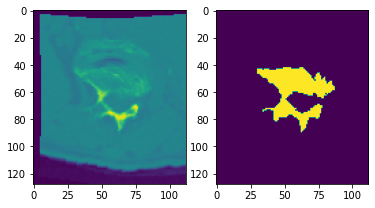

In [24]:
# 验证弹性变形后的数据内容
X = read_npy(images_Path + images_folders[0] + '_etf' + '/000.bin')
Y = read_npy(masks_Path + masks_folders[0] + '_etf' + '/000.bin')
slice = 50
plt.subplot(1,2,1)
plt.imshow((np.squeeze(X.numpy()[slice,:,:]) + 1)/2)
plt.subplot(1,2,2)
plt.imshow(np.squeeze(Y.numpy()[slice,:,:]))

### Add noisy

In [25]:
# 原始数据+经过弹性变形的数据，随即选取50%，添加噪声，并保存为bin文件
# 训练时数据集就有0.25是正常样本，0.25为弹性形变样本，0.5为添加噪声的正常和弹性形变样本
images_Path = rootPath + SrcmhdFolder + '/ROI/train/images/'
masks_Path = rootPath + SrcmhdFolder + '/ROI/train/masks/'

cases = sorted(glob(images_Path + '*/*.bin'))
labels = sorted(glob(masks_Path + '*/*.bin'))

In [26]:
cases,labels = permutation(cases,labels,2020)

[43 12 93 23 87 72 44 60 47 88 41 58 49 59  7 89 25 81 64 61 31 17 37 53
 13 78 26 39 66 57 50 15  0 45 10 35 54  5 84 40 14 27 30 76 85 16 33  2
 42 92 79 18 19 86 52 73 83 77 94 34 36 46 68  4 70 63 22 75  6 95 21 82
 80  1 65 38 98 20 28 90 69 99 62 55 11 51  9 74 24 32 48 29 56 71  3 91
 97 67  8 96]
['/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/images/Splt_image010/001.bin'
 '/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/images/Splt_image010_etf/002.bin'
 '/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/images/Splt_image007_etf/002.bin'
 '/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/images/Splt_image001_etf/003.bin'
 '/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/images/Splt_image010_etf/001.bin']
['/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/masks/Splt_image010/001.bin'
 '/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/masks/Splt_image010_etf/002.bin'
 '/home/shu/Dataset/Dataset xVertSeg/Spilt/ROI/train/masks/Splt_image007_etf/002.bin'
 '/home/

In [27]:
cases = cases[:int(len(cases)/2)]
labels = labels[:int(len(labels)/2)]
print(len(cases),len(labels))

50 50


In [28]:
# 保存高斯噪声的数据为bin文件，用于训练
for j in range(0,len(cases),1):
    X = read_npy(cases[j])
    Y = read_npy(labels[j])
    X_np = X.numpy()
    Y_np = Y.numpy()
    X_noisy = noisy("gauss",X_np)

    X_outPath = images_Path + '/images_noisy/'
    Y_outPath = masks_Path + '/masks_noisy/'
    if not os.path.exists(X_outPath):
        os.makedirs(X_outPath)
    if not os.path.exists(Y_outPath):
        os.makedirs(Y_outPath)

    X_noisy.tofile(X_outPath + str('%03d'%j) + '.bin')
    Y_np.tofile(Y_outPath + str('%03d'%j) + '.bin')

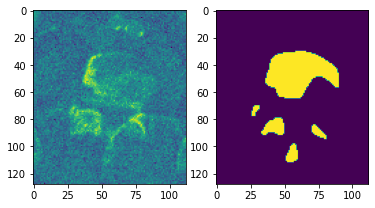

In [29]:
# 验证添加高斯噪声后的信息
X = read_npy(images_Path + '/images_noisy/' + '/000.bin')
Y = read_npy(masks_Path + '/masks_noisy/' + '/000.bin')
slice = 50
plt.subplot(1,2,1)
plt.imshow((np.squeeze(X.numpy()[slice,:,:]) + 1)/2)
plt.subplot(1,2,2)
plt.imshow(np.squeeze(Y.numpy()[slice,:,:]))